# Extended Forecastability Showcase

This walkthrough is the sibling-repository Phase 3 narrative surface for the extended forecastability fingerprint added in v0.4.2.

It stays AMI-first throughout: the lag-geometry block remains the primary forecastability cue, while spectral, ordinal, classical, and memory diagnostics add context around that cue rather than replacing it.

Sections:
- What the extended fingerprint adds beyond AMI geometry alone
- Deterministic seven-series panel generation
- AMI-first extended analysis and verification summary
- Summary and routing tables
- Figure generation into a sibling outputs path
- How to read predictability sources and routing families
- Per-series highlights
- Caveats and the downstream hand-off boundary

## AMI-first framing

The extended fingerprint does not try to jump around deterministic forecastability triage. It starts from accepted AMI structure and then asks whether additive diagnostics reinforce a seasonal, trend-dominated, nonlinear, or long-memory reading.

This notebook does not fit downstream models. It stops at deterministic routing guidance and leaves any forecast-prep or framework-specific work as a separate hand-off step.

In [1]:
%matplotlib inline

from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from forecastability import run_extended_forecastability_analysis
from forecastability.reporting.extended_fingerprint_showcase import (
    build_extended_fingerprint_showcase_record,
    extended_profile_frame,
    routing_table_frame,
    save_metric_overview,
    save_showcase_profile_grid,
    showcase_summary_frame,
    verify_showcase_records,
    write_frame_csv,
)
from forecastability.utils.synthetic import generate_extended_fingerprint_showcase_panel

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.precision", 4)

## What the extended fingerprint adds

The AMI geometry block already tells us whether lag structure survives surrogate correction and how far that structure persists. The extended fingerprint adds deterministic context around that primary signal:

- spectral concentration: whether recurring power reinforces a periodic reading,
- ordinal redundancy: whether the series shows structured nonlinear repetition,
- classical structure: whether seasonality or trend-dominated nonstationarity is visible with a supplied period,
- memory diagnostics: whether persistence across scales adds a conservative long-memory cue.

The package routing surface then reads those blocks together and emits family-level guidance, not exact-model selection.

In [2]:
CWD = Path.cwd().resolve()

if (CWD / "pyproject.toml").exists() and (CWD / "walkthroughs").exists():
    REPO_ROOT = CWD
elif CWD.name == "walkthroughs" and (CWD.parent / "pyproject.toml").exists():
    REPO_ROOT = CWD.parent
else:
    raise RuntimeError(
        "Run this notebook from the forecastability-examples repo root or its walkthroughs directory."
    )

OUTPUT_ROOT = REPO_ROOT / "outputs" / "notebooks" / "walkthroughs" / "08_extended_forecastability_showcase"
FIG_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"
PROFILE_DIR = TABLE_DIR / "ami_profiles"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
PROFILE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
N_OBS = 360
MAX_LAG = 18
SEASONAL_PERIOD = 12

OUTPUT_ROOT

PosixPath('/Users/adamkrysztopa/projects/papers/forecastability-examples/outputs/notebooks/walkthroughs/08_extended_forecastability_showcase')

## Deterministic seven-series panel

The showcase panel is generated from the core package rather than rebuilt locally. It spans a null baseline, clean seasonality, noisy seasonality, short-memory autoregression, trend-dominated structure, a long-memory candidate, and a nonlinear structured signal.

That breadth matters because the notebook is meant to show how the additive blocks reinforce or stay quiet around the same AMI-first workflow.

In [3]:
panel = generate_extended_fingerprint_showcase_panel(
    n=N_OBS,
    seed=SEED,
    seasonal_period=SEASONAL_PERIOD,
)

panel_overview = pd.DataFrame(
    [
        {
            "series_name": case.series_name,
            "generator": case.generator,
            "period": case.period,
            "description": case.description,
            "expected_story": case.expected_story,
        }
        for case in panel
    ]
)
panel_overview

,series_name,generator,period,description,expected_story
0,white_noise,generate_white_noise,NaN,IID Gaussian noise used as the AMI-first null baseline.,Lag geometry and the additive diagnostics should stay weak enough to keep the route on simple baseline families.
1,clean_sine_wave,generate_sine_wave,12.0,Near-noiseless sine wave with a fixed seasonal period.,"AMI geometry should show stable repeating structure, with spectral and seasonality diagnostics reinforcing the recurring signal story."
2,seasonal_plus_noise,generate_additive_seasonal_plus_noise,12.0,Additive seasonal signal with moderate observational noise.,AMI should retain usable seasonal signal while the additive diagnostics show a noisier but still seasonal structure than the clean sine case.
3,ar1,generate_ar1_monotonic,NaN,Short-memory AR(1) process with monotone lag decay.,AMI should detect lag dependence with a compact autoregressive routing story rather than a seasonal or nonlinear one.
4,trend_plus_noise,generate_linear_trend_plus_noise,NaN,Linear deterministic trend with additive Gaussian noise.,The AMI-first view should show lagged structure while the classical block surfaces trend-dominated nonstationarity.
5,long_memory_candidate,generate_long_memory_archetype + normalized_moving_average_blend,NaN,Persistent long-memory proxy blended with a short-range smooth component so the AMI-first lag cue remains visible.,AMI should retain a short lag-dependence cue while the memory block adds a persistence-across-scales cue rather than replacing the AMI-first story.
6,henon_map,generate_henon_map + lag_product_measurement,NaN,Nonlinear lag-product measurement derived from a deterministic Henon map trajectory.,AMI should remain the primary gate while ordinal redundancy provides the strongest nonlinear cue in the panel beyond the seasonal sine examples.


## AMI-first extended analysis

Each series below goes through the implemented core use case `run_extended_forecastability_analysis(...)`. The notebook keeps the science in the package and only orchestrates the deterministic reporting surface.

The sibling walkthrough writes reusable tables to the notebook output tree when you run it locally.

In [4]:
records = []
for case in panel:
    analysis = run_extended_forecastability_analysis(
        case.series,
        name=case.series_name,
        max_lag=MAX_LAG,
        period=case.period,
        random_state=SEED,
    )
    records.append(
        build_extended_fingerprint_showcase_record(
            case=case,
            analysis=analysis,
        )
    )

summary_frame = showcase_summary_frame(records)
routing_frame = routing_table_frame(records)
verification_issues = verify_showcase_records(records)

summary_frame.head()

,target_name,generator,period,signal_to_noise,information_horizon,information_structure,spectral_predictability,spectral_concentration,ordinal_redundancy,trend_strength,seasonal_strength,dfa_alpha,signal_strength,predictability_sources,recommended_model_families
0,white_noise,generate_white_noise,NaN,0.2188,0,none,0.0804,0.0240,0.0047,0.0015,NaN,0.4988,low,-,"naive, seasonal_naive, downscope"
1,clean_sine_wave,generate_sine_wave,12.0,0.9860,18,periodic,0.8326,0.6587,0.2960,0.0006,0.9998,0.5512,high,"lag_dependence, spectral_concentration, seasonality, ordinal_redundancy","arima, ets, linear_state_space, harmonic_regression, tbats, seasonal_naive, seasonal_state_space, tree_on_lags, nonlinear_tabular, tcn"
2,seasonal_plus_noise,generate_additive_seasonal_plus_noise,12.0,0.7831,18,periodic,0.4701,0.4464,0.0062,0.0028,0.6911,0.5235,high,"lag_dependence, seasonality","arima, ets, linear_state_space, seasonal_naive, harmonic_regression, tbats, seasonal_state_space"
3,ar1,generate_ar1_monotonic,NaN,0.6964,4,monotonic,0.3227,0.1327,0.0144,0.0246,NaN,1.0944,high,lag_dependence,"arima, ets, linear_state_space"
4,trend_plus_noise,generate_linear_trend_plus_noise,NaN,0.9674,18,monotonic,0.0883,0.0357,0.0019,0.9561,NaN,1.0505,high,"lag_dependence, trend","arima, ets, linear_state_space, differenced_arima, local_linear_trend"


## Verification summary

The showcase helper includes a coarse deterministic verifier. It checks that the canonical panel order is preserved, that metadata round-trips cleanly, and that the per-series AMI-first semantic story stays within the expected high-level bounds.

An empty issue list means the notebook and the packaged showcase helpers agree structurally.

In [5]:
verification_summary = pd.DataFrame(
    [
        {
            "status": "PASS" if not verification_issues else "FAIL",
            "issues": len(verification_issues),
            "series_count": len(records),
            "output_root": str(OUTPUT_ROOT),
        }
    ]
)

display(verification_summary)
verification_issues

,status,issues,series_count,output_root
0,PASS,0,7,/Users/adamkrysztopa/projects/papers/forecastability-examples/outputs/notebooks/walkthroughs/08_extended_forecastability_showcase


[]

## Summary and routing tables

The first table keeps the compact metric surface visible. The second keeps the route-oriented reading visible: signal strength, noise risk, predictability sources, and the family groups the deterministic router prefers or avoids.

When you run the notebook, the same tables are written under the sibling-repo outputs directory.

In [6]:
write_frame_csv(summary_frame, output_path=TABLE_DIR / "extended_summary.csv")
write_frame_csv(routing_frame, output_path=TABLE_DIR / "extended_routing.csv")

for record in records:
    write_frame_csv(
        extended_profile_frame(record),
        output_path=PROFILE_DIR / f"{record.series_name}_ami_profile.csv",
    )

display(
    summary_frame[[
        "target_name",
        "signal_to_noise",
        "information_horizon",
        "spectral_predictability",
        "ordinal_redundancy",
        "trend_strength",
        "seasonal_strength",
        "dfa_alpha",
        "predictability_sources",
    ]]
)

display(
    routing_frame[[
        "target_name",
        "signal_strength",
        "noise_risk",
        "predictability_sources",
        "recommended_model_families",
        "avoid_model_families",
    ]]
)

,target_name,signal_to_noise,information_horizon,spectral_predictability,ordinal_redundancy,trend_strength,seasonal_strength,dfa_alpha,predictability_sources
0,white_noise,0.2188,0,0.0804,0.0047,0.0015,NaN,0.4988,-
1,clean_sine_wave,0.9860,18,0.8326,0.2960,0.0006,0.9998,0.5512,"lag_dependence, spectral_concentration, seasonality, ordinal_redundancy"
2,seasonal_plus_noise,0.7831,18,0.4701,0.0062,0.0028,0.6911,0.5235,"lag_dependence, seasonality"
3,ar1,0.6964,4,0.3227,0.0144,0.0246,NaN,1.0944,lag_dependence
4,trend_plus_noise,0.9674,18,0.0883,0.0019,0.9561,NaN,1.0505,"lag_dependence, trend"
5,long_memory_candidate,0.5659,4,0.1433,0.0086,0.0081,NaN,0.9422,"lag_dependence, long_memory"
6,henon_map,0.9696,18,0.1965,0.4041,0.0003,NaN,0.2161,"lag_dependence, ordinal_redundancy"


,target_name,signal_strength,noise_risk,predictability_sources,recommended_model_families,avoid_model_families
0,white_noise,low,high,-,"naive, seasonal_naive, downscope","tree_on_lags, tcn, nbeats, nhits, nonlinear_tabular, tbats"
1,clean_sine_wave,high,low,"lag_dependence, spectral_concentration, seasonality, ordinal_redundancy","arima, ets, linear_state_space, harmonic_regression, tbats, seasonal_naive, seasonal_state_space, tree_on_lags, nonlinear_tabular, tcn",-
2,seasonal_plus_noise,high,medium,"lag_dependence, seasonality","arima, ets, linear_state_space, seasonal_naive, harmonic_regression, tbats, seasonal_state_space","tree_on_lags, tcn, nbeats, nhits, nonlinear_tabular"
3,ar1,high,medium,lag_dependence,"arima, ets, linear_state_space","tree_on_lags, tcn, nbeats, nhits, nonlinear_tabular, tbats"
4,trend_plus_noise,high,medium,"lag_dependence, trend","arima, ets, linear_state_space, differenced_arima, local_linear_trend","tree_on_lags, tcn, nbeats, nhits, nonlinear_tabular, tbats"
5,long_memory_candidate,high,medium,"lag_dependence, long_memory","arima, ets, linear_state_space, long_window_ar, fractional_differencing_candidate","tree_on_lags, tcn, nbeats, nhits, nonlinear_tabular, tbats"
6,henon_map,high,medium,"lag_dependence, ordinal_redundancy","arima, ets, linear_state_space, tree_on_lags, nonlinear_tabular, tcn",tbats


## Figure generation

The reporting helpers below reuse the core package figure logic. The profile grid keeps corrected AMI and acceptance thresholds visible. The metric overview puts the additive diagnostic blocks next to the AMI-first metrics so you can compare reinforcement patterns across the panel.

Both figures are written to the sibling outputs path when the notebook runs.

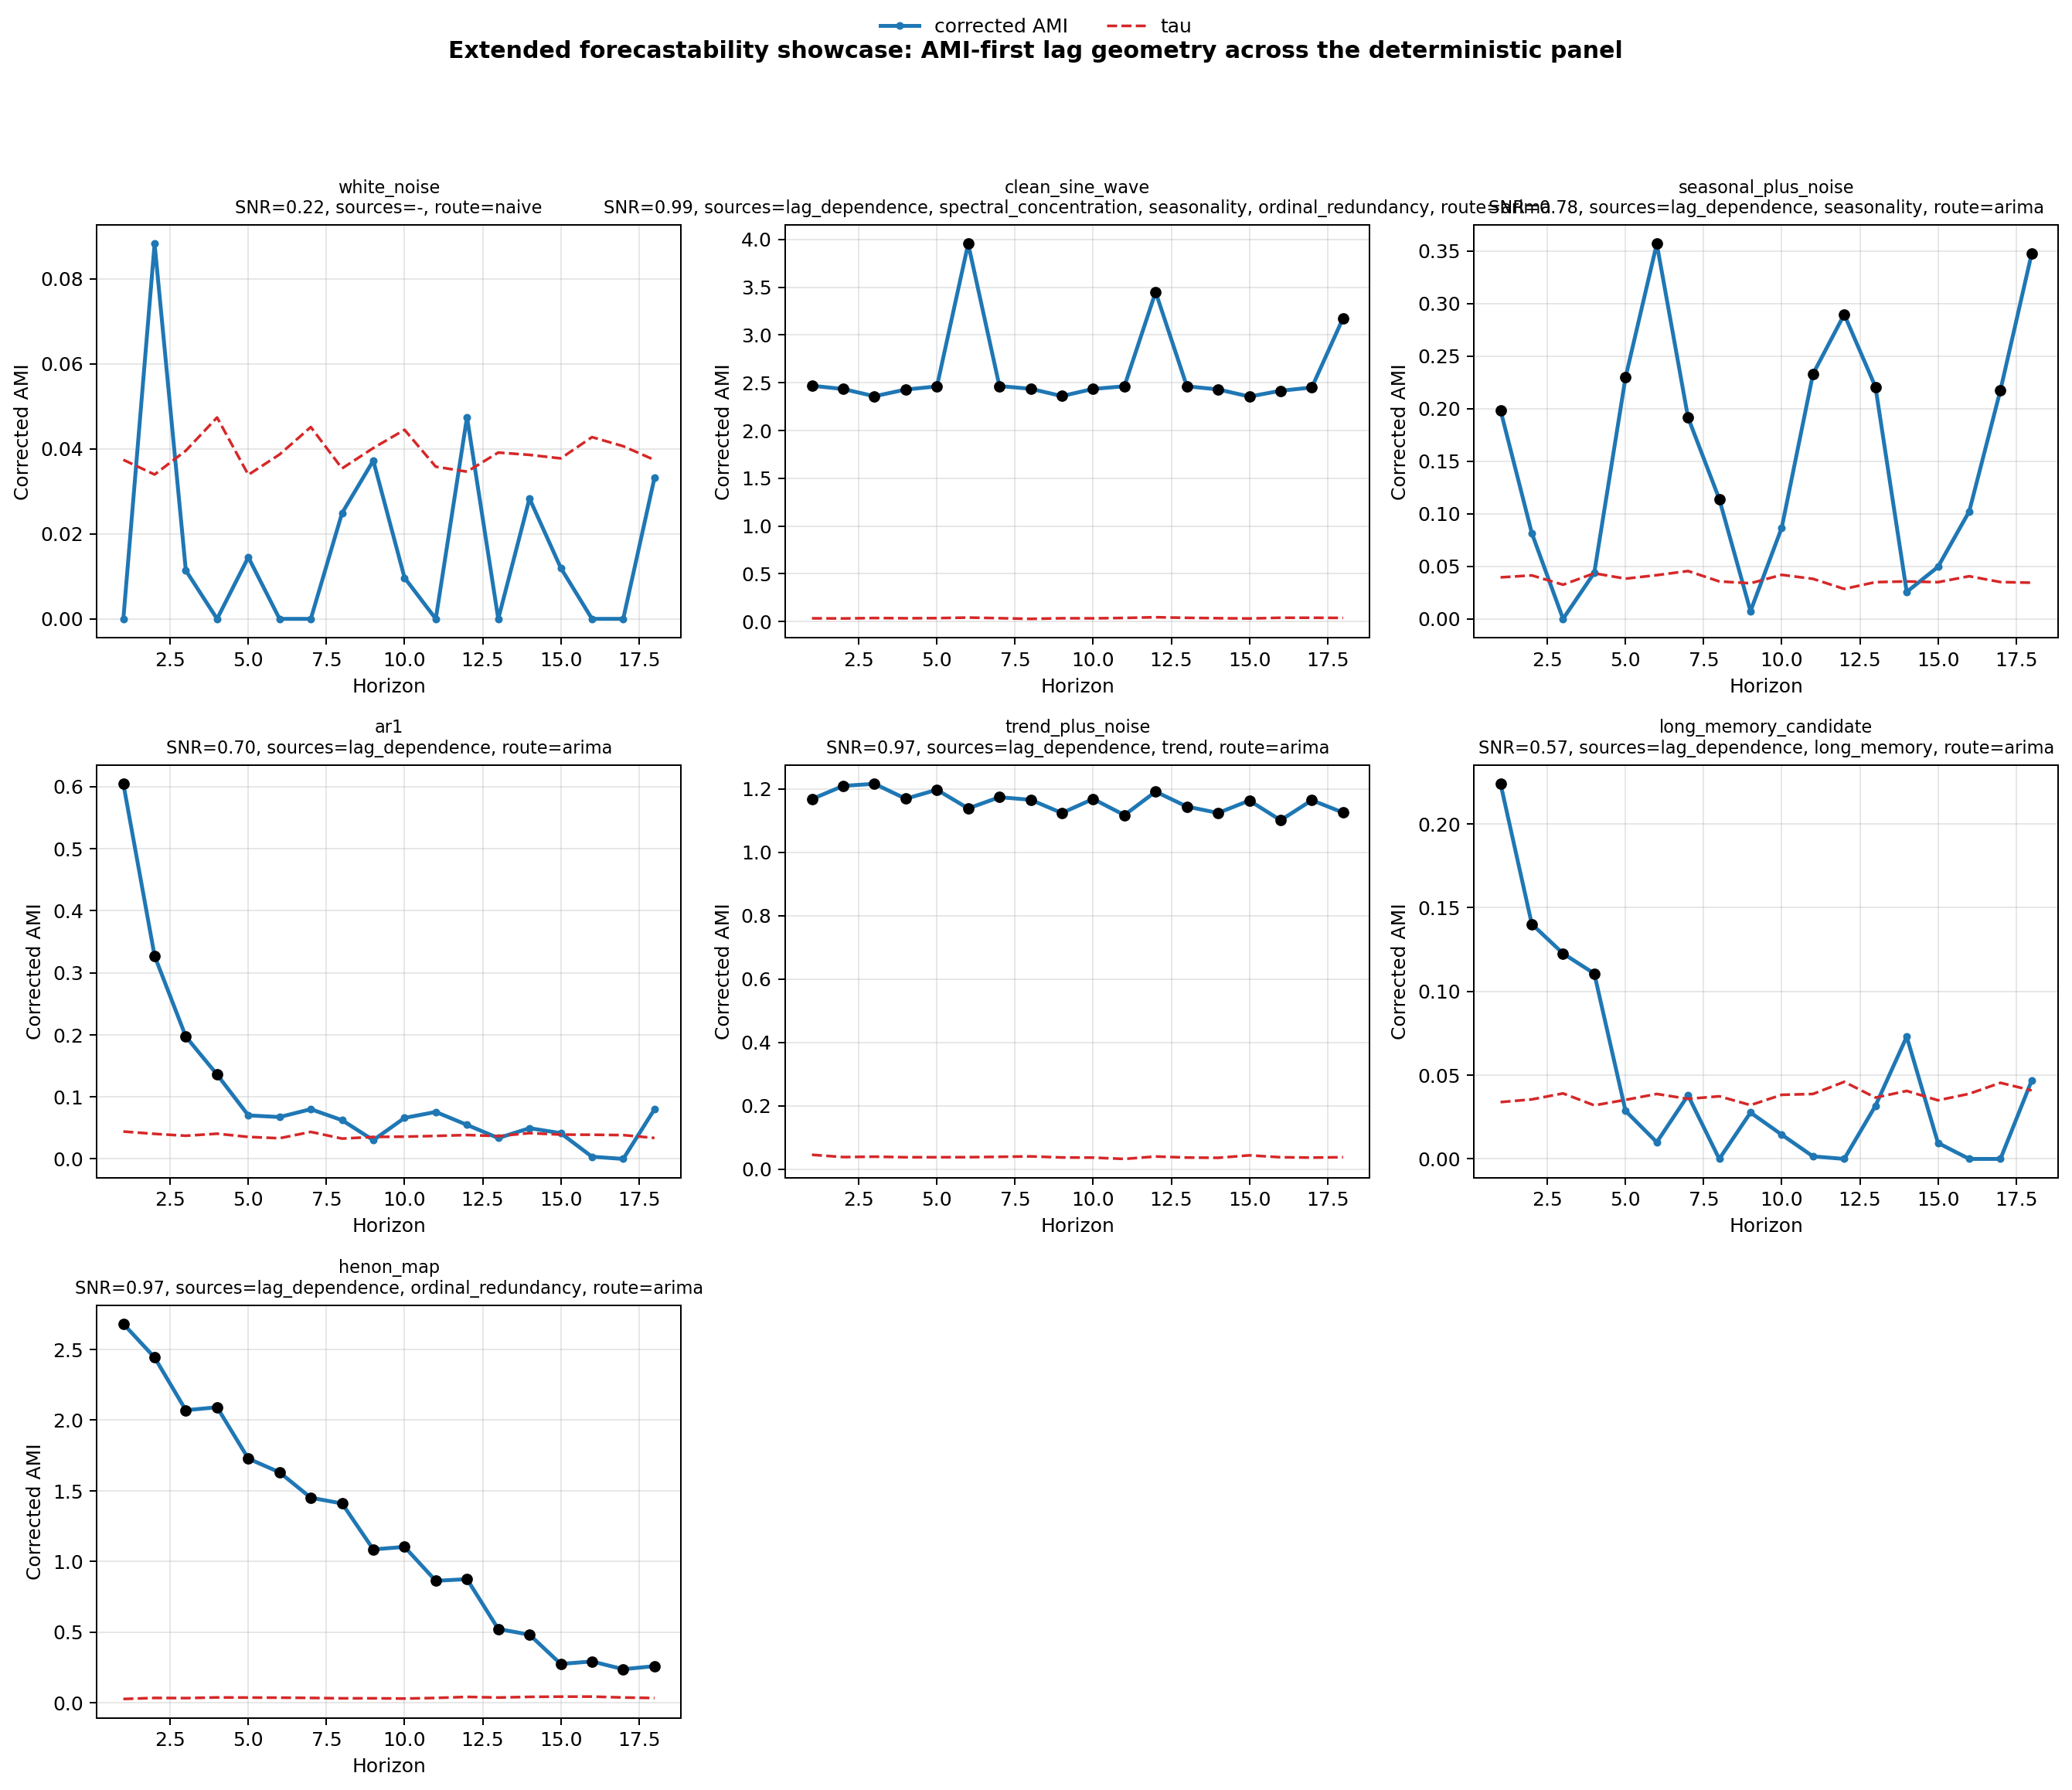

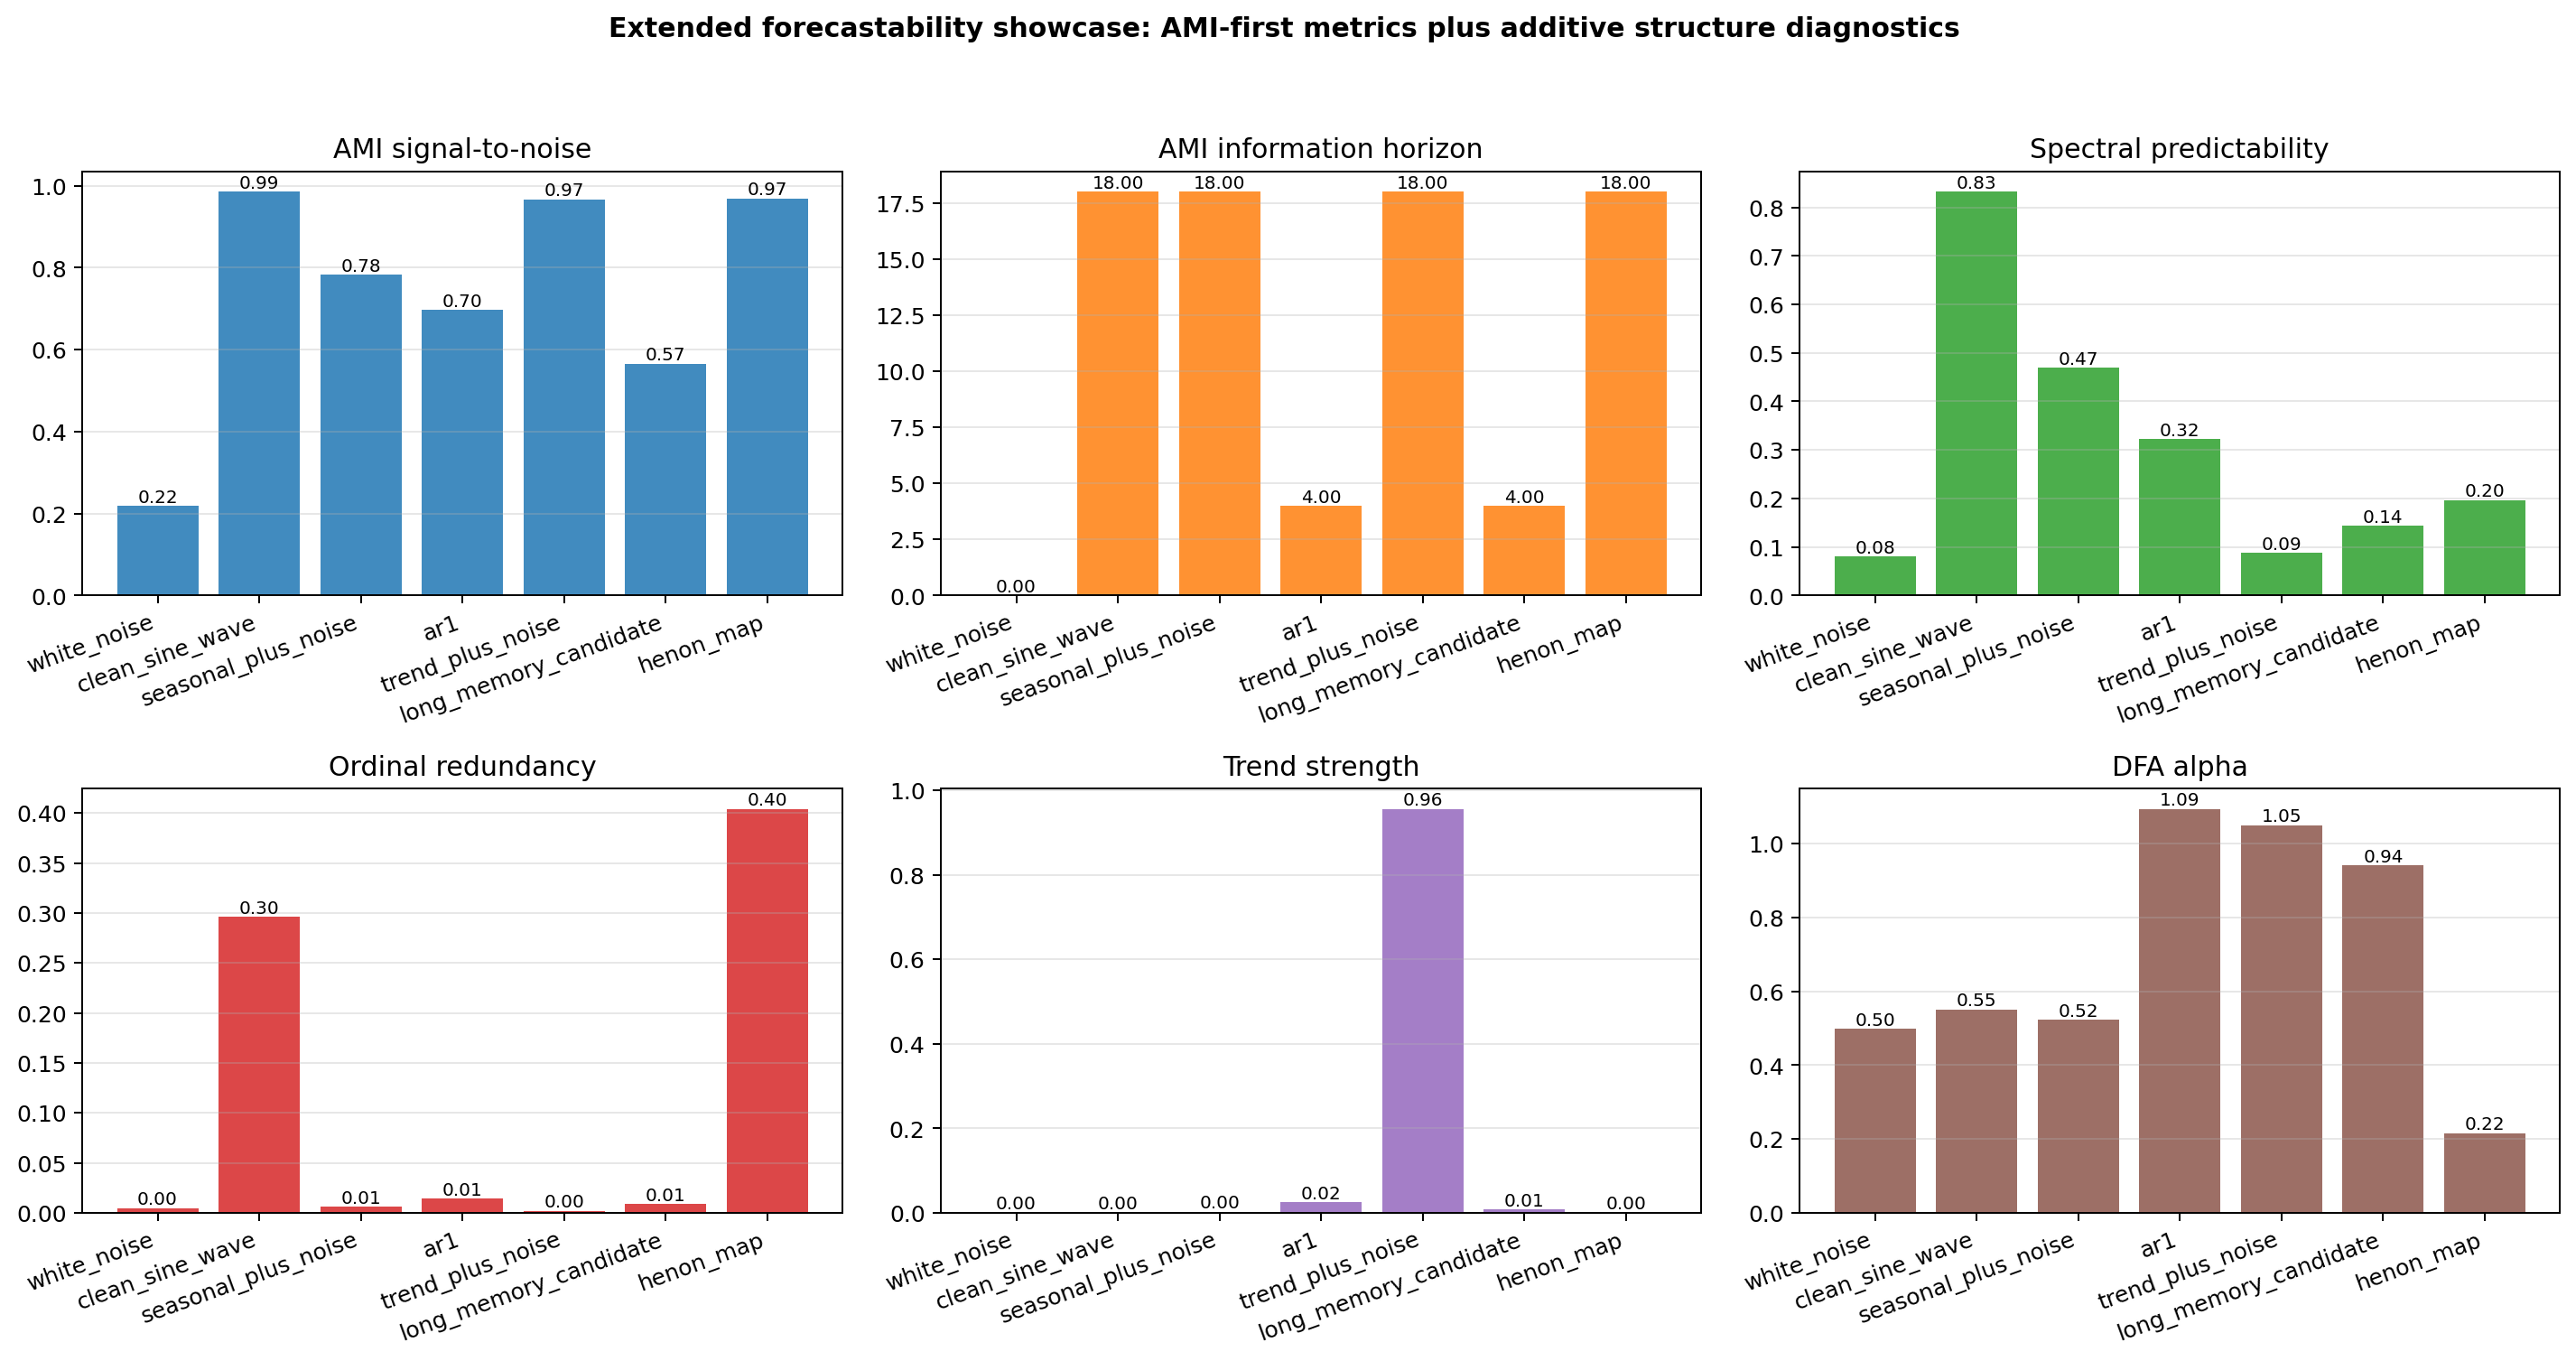

In [7]:
profile_path = FIG_DIR / "extended_ami_profiles.png"
metric_path = FIG_DIR / "extended_metric_overview.png"

save_showcase_profile_grid(records, output_path=profile_path)
save_metric_overview(records, output_path=metric_path)

display(Image(filename=str(profile_path)))
display(Image(filename=str(metric_path)))

## How to read sources and routes

Read `predictability_sources` as additive evidence tags rather than competing winners:

- `lag_dependence`: accepted corrected AMI survives long enough to matter.
- `spectral_concentration`: recurring spectral power reinforces a periodic reading around the AMI cue.
- `seasonality`: the classical block reinforces a period-aware seasonal interpretation.
- `trend`: the classical block points to trend-dominated nonstationarity.
- `ordinal_redundancy`: the ordinal block suggests structured nonlinear repetition around the lag signal.
- `long_memory`: the memory block suggests persistence across scales without replacing the AMI-first story.

Read `recommended_model_families` and `avoid_model_families` as deterministic routing guidance only. They are not fitted models, forecast scores, or a claim that one exact estimator is already justified.

## Per-series highlights

This compact table keeps the expected narrative, the fired predictability sources, and the route-level summary side by side for all seven synthetic cases.

In [8]:
highlights_frame = pd.DataFrame(
    [
        {
            "target_name": record.series_name,
            "expected_story": record.expected_story,
            "predictability_sources": 
            ", \
-",
            "recommended_model_families": 
            ", \
-",
            "avoid_model_families": 
            ", \
-",
            "summary": record.analysis.profile.summary,
        }
        for record in records
    ]
)

write_frame_csv(highlights_frame, output_path=TABLE_DIR / "extended_highlights.csv")
highlights_frame

,target_name,expected_story,predictability_sources,recommended_model_families,avoid_model_families,summary
0,white_noise,Lag geometry and the additive diagnostics should stay weak enough to keep the route on simple baseline families.,", -",", -",", -","Peak forecastability at horizon 2, 0 informative horizon(s) identified."
1,clean_sine_wave,"AMI geometry should show stable repeating structure, with spectral and seasonality diagnostics reinforcing the recurring signal story.",", -",", -",", -","Peak forecastability at horizon 6, 18 informative horizon(s) identified."
2,seasonal_plus_noise,AMI should retain usable seasonal signal while the additive diagnostics show a noisier but still seasonal structure than the clean sine case.,", -",", -",", -","Peak forecastability at horizon 6, 10 informative horizon(s) identified."
3,ar1,AMI should detect lag dependence with a compact autoregressive routing story rather than a seasonal or nonlinear one.,", -",", -",", -","Peak forecastability at horizon 1, 4 informative horizon(s) identified."
4,trend_plus_noise,The AMI-first view should show lagged structure while the classical block surfaces trend-dominated nonstationarity.,", -",", -",", -","Peak forecastability at horizon 3, 18 informative horizon(s) identified."
5,long_memory_candidate,AMI should retain a short lag-dependence cue while the memory block adds a persistence-across-scales cue rather than replacing the AMI-first story.,", -",", -",", -","Peak forecastability at horizon 1, 4 informative horizon(s) identified."
6,henon_map,AMI should remain the primary gate while ordinal redundancy provides the strongest nonlinear cue in the panel beyond the seasonal sine examples.,", -",", -",", -","Peak forecastability at horizon 1, 18 informative horizon(s) identified."


## Caveats

- This notebook is deterministic and synthetic. It demonstrates interpretation surfaces, not real-world performance claims.
- The additive diagnostics reinforce or contextualize lag geometry; they do not certify forecast accuracy.
- A noisy or short real series can yield muted or unavailable blocks, and that is part of the intended triage story rather than an error.
- The routing output is family-level guidance only. It is deliberately upstream of any downstream model fitting or benchmark comparison.

## Hand-off boundary

This sibling walkthrough stops at the deterministic extended forecastability analysis. If you want to continue, run the notebook locally, inspect the written tables and figures under `outputs/notebooks/walkthroughs/08_extended_forecastability_showcase/`, and then choose a separate downstream hand-off path.

That next step can include forecast-prep or framework-specific experimentation elsewhere, but it should happen only after the AMI-first triage story above is understood and accepted.